# All Code

In [1]:
import pandas as pd
import os

In [2]:
def extract_ip_addresses_from_dns_info(info_str):
    words = info_str.split(' ')
    ips = []
    
    for w in words:
        if len(w.split('.')) == 4:
            ips.append(w)
    return ips

In [34]:
def get_open_website_ips(df, website_name):
    dns_packets = df[df["Protocol"] == "DNS"].iterrows()
    open_router_ips = []
    
    for row in dns_packets:
        info_str = row[1]["Info"]
        if ("Standard query response" in info_str) and (website_name in info_str):
            new_open_router_ips = extract_ip_addresses_from_dns_info(info_str)
            open_router_ips.extend(new_open_router_ips)          
    return list(set(open_router_ips))

In [35]:
# def get_website_mask(source_df, ips_list):

#     mask = None
#     for ip in ips_list:
#         if mask is None:
#             mask = (source_df['Source'] == ip) | (source_df['Destination'] == ip)
#         else:
#             mask = (current_mask) | ( (source_df['Source'] == ip) | (source_df['Destination'] == ip) )
#     return mask

In [36]:
def split_df_into_api_segments(df, open_router_ips):
    
    # 2d array where each list corresponds to an api call and the contents of the list are the
    # idxs in the dataframe corresponding to that activity
    idxs = []
    current_segment = []

    for i, row in df.iterrows():
        info_str = row['Info']
        if ("Standard query response" in info_str) and ('zephaniahdev.com' in info_str):
            idxs.append(current_segment)
            current_segment = []
        else:
            if len(current_segment) == 0:
                if row['Source'] not in open_router_ips and row['Destination'] not in open_router_ips:
                    continue
            current_segment.append(i)

    dfs = []
    for segment in idxs:
        # used claude to know the proper syntax here
        # https://claude.ai/share/28847658-d5bc-4b08-93dd-f71e9240b13f
        dfs.append(df.iloc[segment].copy())

    return dfs

In [62]:
non_zero_segmnets = []

for i, s in enumerate(segments):
    if len(s) == 0: print("here", i)
    else:
        s_open = s[s['Source'].isin(open_router_ips) | s['Destination'].isin(open_router_ips) ]
        non_zero_segmnets.append(s_open)

here 81


In [63]:
import json

with open('src/labels.json', 'r') as f:
    labels = json.load(f)

In [67]:
# labels

[{'prompt_tokens': 18, 'completion_tokens': 1329, 'cost': 0.00066945},
 {'prompt_tokens': 49, 'completion_tokens': 2984, 'cost': 0.0014959},
 {'prompt_tokens': 84, 'completion_tokens': 1378, 'cost': 0.0007133},
 {'prompt_tokens': 40, 'completion_tokens': 1023, 'cost': 0.00052305},
 {'prompt_tokens': 39, 'completion_tokens': 1892, 'cost': 0.000957025},
 {'prompt_tokens': 64, 'completion_tokens': 1196, 'cost': 0.00061675},
 {'prompt_tokens': 231, 'completion_tokens': 526, 'cost': 0.00033185},
 {'prompt_tokens': 89, 'completion_tokens': 1083, 'cost': 0.00056775},
 {'prompt_tokens': 11, 'completion_tokens': 347, 'cost': 0.00017635},
 {'prompt_tokens': 15, 'completion_tokens': 591, 'cost': 0.00029955},
 {'prompt_tokens': 44, 'completion_tokens': 935, 'cost': 0.00048025},
 {'prompt_tokens': 11, 'completion_tokens': 416, 'cost': 0.000210625},
 {'prompt_tokens': 17, 'completion_tokens': 490, 'cost': 0.000249425},
 {'prompt_tokens': 44, 'completion_tokens': 1562, 'cost': 0.00079375},
 {'prompt_

In [68]:
ts = [l['completion_tokens'] for l in labels]
ts2 = [l['prompt_tokens'] for l in labels]
lens = [sum(segment['Length']) for segment in non_zero_segmnets]

In [65]:
len(lens), len(ts)

(151, 151)

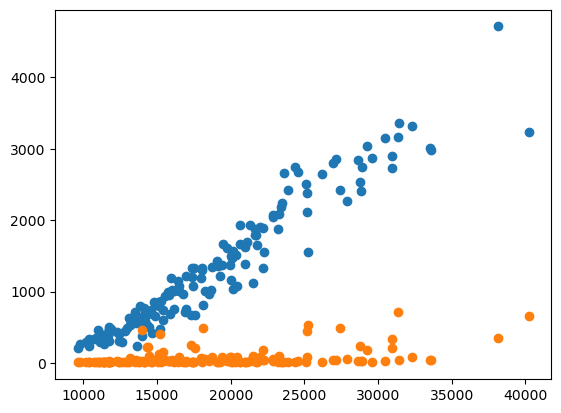

In [70]:
plt.scatter(lens, ts)
plt.scatter(lens, ts2)

In [61]:
max(lens)

23586381

In [37]:
df = pd.read_csv("pcaps/first_full_run.csv", encoding='latin-1')

open_router_ips = get_open_website_ips(df, "openrouter.ai")
# zephaniah_dev_ips = get_open_website_ips(df, "zephaniahdev.com")

In [38]:
open_router_ips

['104.18.2.115', '104.18.3.115']

In [45]:
only_open_router = df[df['Source'].isin(open_router_ips) | df['Destination'].isin(open_router_ips) ]

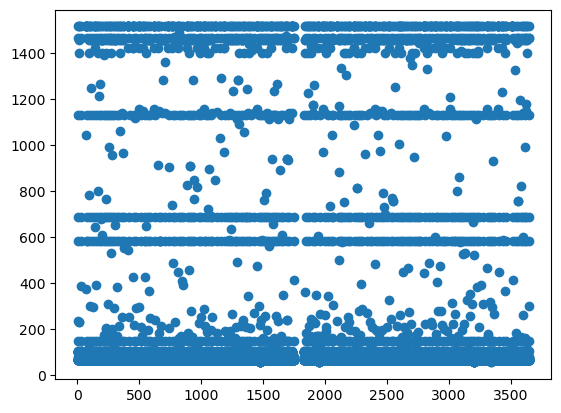

In [46]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'])
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
plt.show()

In [39]:
segments = split_df_into_api_segments(df, open_router_ips)

In [40]:
only_open_router = segments[2][segments[2]['Source'].isin(open_router_ips) | segments[2]['Destination'].isin(open_router_ips) ]

In [41]:
len(segments)

152

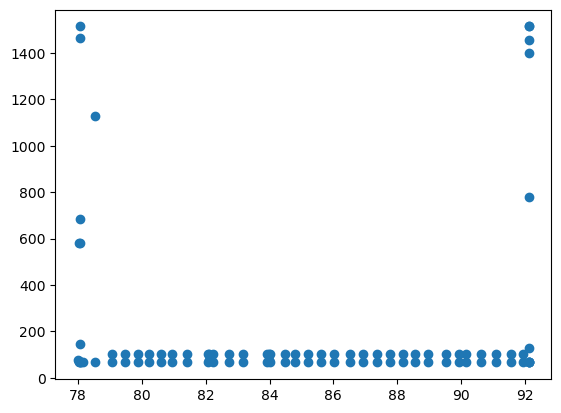

In [44]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'])
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
plt.show()

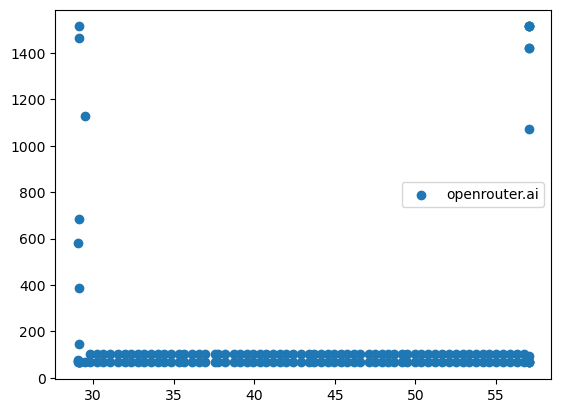

In [316]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

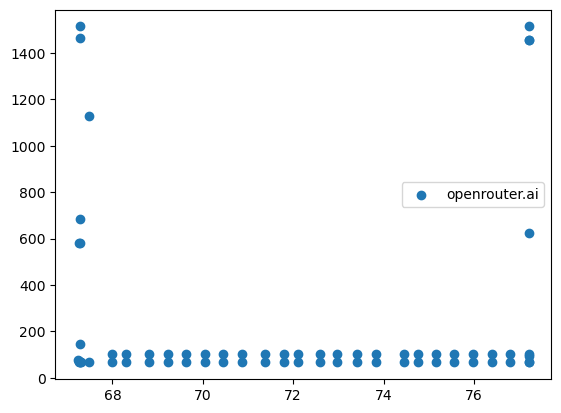

In [323]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [256]:
np.array(get_website_mask(df, open_router_ips))

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [253]:
import matplotlib.pyplot as plt
full = pd.read_csv("pcaps/test1.csv", encoding='latin-1')
open_router_ips = get_open_website_ips(df, "openrouter.ai")

only_open_router = full[get_website_mask(full, open_router_ips)]
# only_zephaniah_dev = df[get_website_mask(df, zephaniah_dev_ips)]

# plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
# # plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
# plt.legend()
# plt.show()

In [254]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,3.404999,192.168.111.43,104.18.3.115,TCP,78,60505 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,60505.0,60505.0,23
23,24,3.429753,104.18.3.115,192.168.111.43,TCP,74,"443 > 60505 [SYN, ACK] Seq=0 Ack=1 Win=65535...",60505.0,60505.0,443.0,443.0,24
24,25,3.429859,192.168.111.43,104.18.3.115,TCP,66,60505 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,60505.0,60505.0,25
25,26,3.430176,192.168.111.43,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,60505.0,60505.0,26
26,27,3.460792,104.18.3.115,192.168.111.43,TCP,66,443 > 60505 [ACK] Seq=1 Ack=518 Win=131072 L...,60505.0,60505.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,7.673535,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.102? Tell 192.168.111.75,NaN,NaN,NaN,NaN,154
154,155,7.718554,17.171.47.23,192.168.111.43,TCP,60,443 > 60487 [RST] Seq=33 Win=0 Len=0,60487.0,60487.0,443.0,443.0,155
209,210,9.308719,192.168.111.43,17.171.47.23,TCP,66,60496 > 443 [ACK] Seq=1 Ack=33 Win=88 Len=0 ...,443.0,443.0,60496.0,60496.0,210
213,214,9.360930,17.171.47.23,192.168.111.43,TCP,60,443 > 60496 [RST] Seq=33 Win=0 Len=0,60496.0,60496.0,443.0,443.0,214


In [182]:
df

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
0,1,0.000000,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.149? Tell 192.168.111.75,NaN,NaN,NaN,NaN,1
1,2,0.205246,ASUSTekCOMPU_1f:de:80,Apple_1c:fe:8a,ARP,60,Who has 192.168.111.43? Tell 192.168.111.1,NaN,NaN,NaN,NaN,2
2,3,0.205367,Apple_1c:fe:8a,ASUSTekCOMPU_1f:de:80,ARP,42,192.168.111.43 is at 3c:a6:f6:1c:fe:8a,NaN,NaN,NaN,NaN,3
3,4,0.301654,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.161? Tell 192.168.111.75,NaN,NaN,NaN,NaN,4
4,5,0.925164,192.168.111.45,224.0.0.251,MDNS,100,Standard query 0x0000 PTR _companion-link._tcp...,5353.0,5353.0,5353.0,5353.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
827,828,90.314933,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.220? Tell 192.168.111.75,NaN,NaN,NaN,NaN,828
828,829,90.625592,192.168.111.153,224.0.0.251,MDNS,120,Standard query 0x0000 SRV HP Color LaserJet Pr...,5353.0,5353.0,5353.0,5353.0,829
829,830,90.931959,192.168.111.17,224.0.0.251,MDNS,204,Standard query 0x0000 PTR _companion-link._tcp...,5353.0,5353.0,5353.0,5353.0,830
830,831,91.244801,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.136? Tell 192.168.111.75,NaN,NaN,NaN,NaN,831


In [181]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,3.404999,192.168.111.43,104.18.3.115,TCP,78,60505 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,60505.0,60505.0,23
23,24,3.429753,104.18.3.115,192.168.111.43,TCP,74,"443 > 60505 [SYN, ACK] Seq=0 Ack=1 Win=65535...",60505.0,60505.0,443.0,443.0,24
24,25,3.429859,192.168.111.43,104.18.3.115,TCP,66,60505 > 443 [ACK] Seq=1 Ack=1 Win=131840 Len...,443.0,443.0,60505.0,60505.0,25
25,26,3.430176,192.168.111.43,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,60505.0,60505.0,26
26,27,3.460792,104.18.3.115,192.168.111.43,TCP,66,443 > 60505 [ACK] Seq=1 Ack=518 Win=131072 L...,60505.0,60505.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,7.673535,8a:96:dd:09:e9:d0,Broadcast,ARP,42,Who has 192.168.111.102? Tell 192.168.111.75,NaN,NaN,NaN,NaN,154
154,155,7.718554,17.171.47.23,192.168.111.43,TCP,60,443 > 60487 [RST] Seq=33 Win=0 Len=0,60487.0,60487.0,443.0,443.0,155
209,210,9.308719,192.168.111.43,17.171.47.23,TCP,66,60496 > 443 [ACK] Seq=1 Ack=33 Win=88 Len=0 ...,443.0,443.0,60496.0,60496.0,210
213,214,9.360930,17.171.47.23,192.168.111.43,TCP,60,443 > 60496 [RST] Seq=33 Win=0 Len=0,60496.0,60496.0,443.0,443.0,214


In [96]:
only_open_router

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
22,23,15.196938,10.150.14.95,104.18.3.115,TCP,78,57361 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57361.0,57361.0,23
23,24,15.208490,104.18.3.115,10.150.14.95,TCP,74,"443 > 57361 [SYN, ACK] Seq=0 Ack=1 Win=65535...",57361.0,57361.0,443.0,443.0,24
24,25,15.208649,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57361.0,57361.0,25
25,26,15.209370,10.150.14.95,104.18.3.115,TLSv1.3,583,Client Hello (SNI=openrouter.ai),443.0,443.0,57361.0,57361.0,26
26,27,15.252591,104.18.3.115,10.150.14.95,TCP,66,443 > 57361 [ACK] Seq=1 Ack=518 Win=131072 L...,57361.0,57361.0,443.0,443.0,27
...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,31.361033,104.18.3.115,10.150.14.95,TLSv1.3,1064,"Application Data, Application Data, Applicatio...",57361.0,57361.0,443.0,443.0,154
154,155,31.361375,10.150.14.95,104.18.3.115,TCP,66,57361 > 443 [ACK] Seq=1336 Ack=10382 Win=131...,443.0,443.0,57361.0,57361.0,155
209,210,54.055280,10.150.14.95,104.18.3.115,TCP,66,"57361 > 443 [FIN, ACK] Seq=1336 Ack=10382 Wi...",443.0,443.0,57361.0,57361.0,210
213,214,54.229522,104.18.3.115,10.150.14.95,TCP,66,"443 > 57361 [FIN, ACK] Seq=10382 Ack=1337 Wi...",57361.0,57361.0,443.0,443.0,214


In [97]:
only_zephaniah_dev

,No.,Time,Source,Destination,Protocol,Length,Info,dest (r),dest(u),src (r),src(u),New Column
164,165,43.620507,10.150.14.95,46.202.197.140,TCP,78,57363 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,443.0,443.0,57363.0,57363.0,165
166,167,43.741637,46.202.197.140,10.150.14.95,TCP,74,"443 > 57363 [SYN, ACK] Seq=0 Ack=1 Win=31856...",57363.0,57363.0,443.0,443.0,167
167,168,43.741828,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=1 Ack=1 Win=131520 Len...,443.0,443.0,57363.0,57363.0,168
168,169,43.777993,10.150.14.95,46.202.197.140,TLSv1.3,583,Client Hello (SNI=zephaniahdev.com),443.0,443.0,57363.0,57363.0,169
169,170,43.896586,46.202.197.140,10.150.14.95,TCP,66,443 > 57363 [ACK] Seq=1 Ack=518 Win=31872 Le...,57363.0,57363.0,443.0,443.0,170
170,171,43.902648,46.202.197.140,10.150.14.95,TLSv1.3,1436,"Server Hello, Change Cipher Spec",57363.0,57363.0,443.0,443.0,171
171,172,43.902651,46.202.197.140,10.150.14.95,TCP,941,[TCP Previous segment not captured] 443 > 57...,57363.0,57363.0,443.0,443.0,172
172,173,43.902652,46.202.197.140,10.150.14.95,TLSv1.3,1436,"[TCP Retransmission] , Application Data",57363.0,57363.0,443.0,443.0,173
173,174,43.902749,10.150.14.95,46.202.197.140,TCP,66,57363 > 443 [ACK] Seq=518 Ack=1371 Win=13011...,443.0,443.0,57363.0,57363.0,174
174,175,43.902819,10.150.14.95,46.202.197.140,TCP,78,[TCP Dup ACK 174#1] 57363 > 443 [ACK] Seq=51...,443.0,443.0,57363.0,57363.0,175


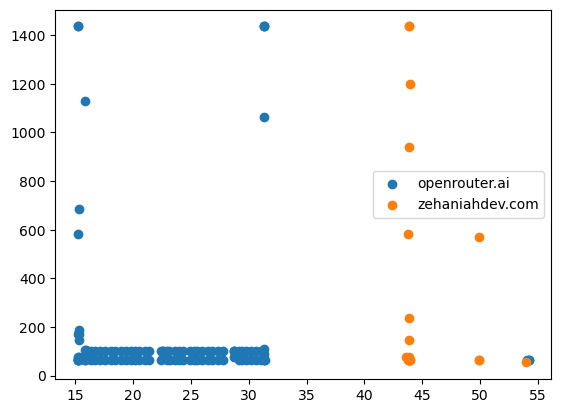

In [98]:
import matplotlib.pyplot as plt

plt.scatter(only_open_router['Time'], only_open_router['Length'], label='openrouter.ai')
plt.scatter(only_zephaniah_dev['Time'], only_zephaniah_dev['Length'],label='zehaniahdev.com')
plt.legend()
plt.show()

In [55]:
df['Source']

0        10.150.14.95
1        10.150.14.95
2        10.150.14.95
3        10.150.14.95
4       17.57.144.135
            ...      
232    17.248.168.168
233    17.248.168.168
234        10.150.0.2
235        10.150.0.2
236      10.150.14.95
Name: Source, Length: 237, dtype: object

In [51]:
(df['Source'] == '104.18.2.115') | (df['Destination'] == '104.18.2.115')

0      False
1      False
2      False
3      False
4      False
       ...  
232    False
233    False
234    False
235    False
236    False
Length: 237, dtype: bool